In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [17]:
print("Environment ready!")
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", __import__("sklearn").__version__)

Environment ready!
NumPy: 2.4.6
pandas: 3.0.3
scikit-learn: 1.9.0


In [18]:
df = pd.read_csv("student_performanc.csv")
df.head()

,student_id,study_hours,attendance,assignments,result
0,1,1.0,58,3,0
1,2,1.5,62,5,0
2,3,2.0,65,6,0
3,4,2.5,68,7,1
4,5,3.0,72,7,1


In [19]:
df.groupby("result")[["study_hours","attendance","assignments"]].mean()

,study_hours,attendance,assignments
result,,,
0,1.633333,65.037037,5.296296
1,3.824242,76.060606,8.393939


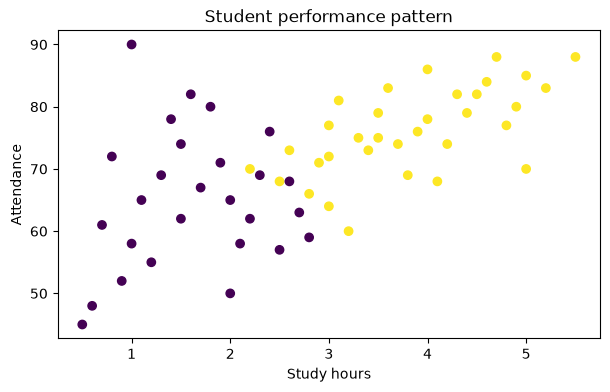

X shape: (60, 3)
y shape: (60,)


In [20]:
plt.figure(figsize=(7,4))
plt.scatter(df["study_hours"], df["attendance"], c=df["result"])
plt.xlabel("Study hours")
plt.ylabel("Attendance")
plt.title("Student performance pattern")
plt.show()



X = df[["study_hours", "attendance", "assignments"]]
y = df["result"]



print("X shape:", X.shape)
print("y shape:", y.shape)

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

model = DecisionTreeClassifier(max_depth=3, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Training rows: 48
Testing rows : 12
Model trained!


In [22]:
predictions = model.predict(X_test)

print ("Predictions:")
print (predictions)
print ("X_test: ")
print (X_test)

Predictions:
[0 1 1 1 1 0 1 0 1 0 1 0]
X_test: 
    study_hours  attendance  assignments
34          0.9          52            6
46          4.1          68            9
15          4.2          74            8
25          5.0          70            9
54          5.2          83           10
45          1.6          82            4
42          4.9          80           10
26          1.7          67            6
48          3.3          75            7
17          1.8          80            5
27          3.6          83            8
19          2.0          50            7


In [23]:
accuracy = accuracy_score(y_test, predictions)
print (f"Test accuracy: {accuracy: .2%}")

Test accuracy:  100.00%


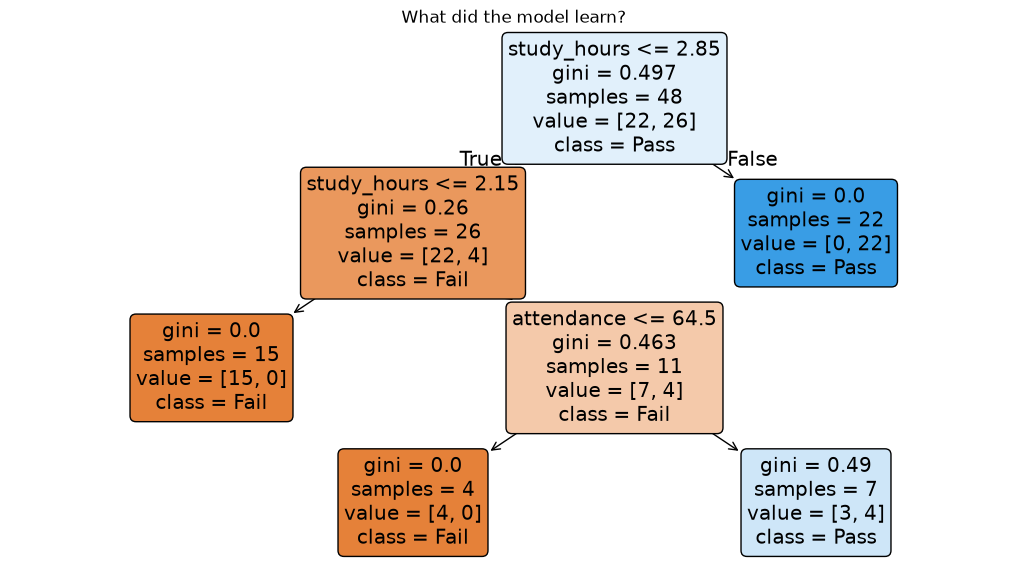

In [15]:
plt.figure(figsize=(13, 7))
plot_tree(
    model, 
    feature_names=X.columns,
    class_names=["Fail", "Pass"],
    filled=True, 
    rounded=True
)
plt.title("What did the model learn?")
plt.show()